
# Interpretable Longitudinal Multi-Omics Disease Prediction
## Synthetic incident type 2 diabetes proof of concept

This notebook is a CPU-friendly proof of concept for a **Sanger-style Human Genetics and Disease Prediction** programme. It simulates a longitudinal, multi-omics cohort for incident type 2 diabetes, then performs exploratory analysis, trajectory analysis, unsupervised subtype discovery, predictive modelling, calibration, subgroup analysis, and feature prioritisation.

The dataset is **synthetic**. It is inspired by directions and broad patterns reported in PubMed-indexed studies, but it is **not** a reconstruction of any specific real cohort. The goal is methodological demonstration, not biological truth claims about any population.

The simulation encodes these benchmark-style assumptions:

- Higher **HbA1c**, **fasting glucose**, and **BMI** increase future diabetes risk.
- Higher **branched-chain amino acids** and **GlycA-like inflammatory signal** increase risk.
- Higher **adiponectin** and **SHBG** reduce risk.
- Higher **ACY1-like protein** increases risk.
- A **polygenic risk score** adds modest predictive signal.
- Model performance can differ across ancestry groups, illustrating **transferability** issues.

Each major code block is followed by a markdown interpretation cell.


In [2]:

# 0. Imports and global settings


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

np.random.seed(42)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11



### Interpretation

This cell loads the scientific Python stack needed for the notebook.

The analysis is intentionally limited to widely available CPU-friendly tools:
- `pandas` and `numpy` for data handling,
- `matplotlib` for figures,
- `scikit-learn` for modelling,
- `scipy` for some statistics and clustering,
- `statsmodels` only if available for classical logistic regression inference.

A fixed random seed is used so that the simulation is reproducible.


In [4]:

# 1. Helper functions


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def zscore_df(df):
    return (df - df.mean()) / df.std(ddof=0)

def add_missingness(df, cols, frac=0.05, seed=42):
    rng = np.random.default_rng(seed)
    out = df.copy()
    n = len(df)
    for c in cols:
        idx = rng.choice(n, size=int(frac * n), replace=False)
        out.loc[idx, c] = np.nan
    return out

def auc_ci_bootstrap(y_true, y_score, n_boot=300, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    aucs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def pr_ci_bootstrap(y_true, y_score, n_boot=300, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    prs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        prs.append(average_precision_score(y_true[idx], y_score[idx]))
    return np.mean(prs), np.percentile(prs, 2.5), np.percentile(prs, 97.5)

def calibration_curve_manual(y_true, y_prob, n_bins=10):
    df = pd.DataFrame({"y": y_true, "p": y_prob})
    df["bin"] = pd.qcut(df["p"], q=n_bins, duplicates="drop")
    cal = df.groupby("bin", observed=True).agg(
        mean_pred=("p", "mean"),
        frac_pos=("y", "mean"),
        n=("y", "size")
    ).reset_index(drop=True)
    return cal

def expected_calibration_error(y_true, y_prob, n_bins=10):
    cal = calibration_curve_manual(y_true, y_prob, n_bins=n_bins)
    total = cal["n"].sum()
    ece = np.sum((cal["n"] / total) * np.abs(cal["frac_pos"] - cal["mean_pred"]))
    return ece, cal

def km_curve(times, events):
    order = np.argsort(times)
    times = np.asarray(times)[order]
    events = np.asarray(events)[order]
    unique_event_times = np.unique(times[events == 1])
    surv_probs = [1.0]
    surv_times = [0.0]
    s = 1.0
    for t in unique_event_times:
        at_risk = np.sum(times >= t)
        d = np.sum((times == t) & (events == 1))
        if at_risk > 0:
            s *= (1 - d / at_risk)
            surv_times.append(t)
            surv_probs.append(s)
    return np.array(surv_times), np.array(surv_probs)

def make_feature_blocks(prefix, n_features):
    return [f"{prefix}_{i+1:02d}" for i in range(n_features)]

def summarize_by_group(df, group_col, target_col):
    return (
        df.groupby(group_col, observed=True)[target_col]
        .agg(["mean", "sum", "count"])
        .rename(columns={"mean": "event_rate", "sum": "events", "count": "n"})
        .reset_index()
    )

def plot_hist_grid(df, cols, ncols=3, bins=30, title=None):
    import math
    n = len(cols)
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
    axes = np.array(axes).reshape(-1)
    for ax, c in zip(axes, cols):
        ax.hist(df[c].dropna(), bins=bins)
        ax.set_title(c)
    for ax in axes[n:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_corr_heatmap(df, cols, title="Correlation heatmap"):
    corr = df[cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr.values, aspect="auto")
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=90)
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()



### Interpretation

These helper functions keep the rest of the notebook readable.

They cover:
- probability transformation,
- simple standardization,
- synthetic missingness,
- bootstrap confidence intervals for AUROC and AUPRC,
- calibration summaries,
- a minimal Kaplan-Meier-like estimator,
- grouped summaries,
- plotting helpers.

Nothing here is disease-specific. These functions are reusable for other longitudinal prediction projects.


In [6]:

# 2. Simulate a longitudinal multi-omics cohort

N = 3500

ancestry = np.random.choice(
    ["EUR_like", "SAS_like", "AFR_like"],
    size=N,
    p=[0.58, 0.24, 0.18]
)

sex = np.random.binomial(1, 0.49, size=N)
age = np.clip(np.random.normal(52, 11, size=N), 25, 80)

bmi_shift = np.select(
    [ancestry == "EUR_like", ancestry == "SAS_like", ancestry == "AFR_like"],
    [0.0, 1.0, 1.4],
    default=0.0
)
bmi = np.clip(np.random.normal(28 + bmi_shift, 4.8, size=N), 18, 50)

smoking = np.random.binomial(1, 0.22, size=N)
physical_activity = np.clip(np.random.normal(0, 1, size=N), -2.5, 2.5)
family_history = np.random.binomial(1, 0.30, size=N)

latent_ir = (
    0.06 * (age - 50)
    + 0.22 * (bmi - 28)
    + 0.45 * family_history
    + 0.28 * smoking
    - 0.30 * physical_activity
    + np.random.normal(0, 1, size=N)
)

latent_inflam = (
    0.04 * (age - 50)
    + 0.14 * (bmi - 28)
    + 0.18 * smoking
    + np.random.normal(0, 1, size=N)
)

latent_beta_failure = (
    0.18 * family_history
    + 0.10 * (age - 50)
    + np.random.normal(0, 1, size=N)
)

prs_base = np.random.normal(0, 1, size=N)
prs_transfer_penalty = np.select(
    [ancestry == "EUR_like", ancestry == "SAS_like", ancestry == "AFR_like"],
    [1.0, 0.85, 0.75],
    default=1.0
)
prs = prs_base * prs_transfer_penalty + 0.25 * family_history + np.random.normal(0, 0.15, size=N)

hba1c = np.clip(
    5.2 + 0.18 * latent_ir + 0.22 * latent_beta_failure + 0.015 * (age - 50) + np.random.normal(0, 0.35, size=N),
    4.2, 8.5
)

fasting_glucose = np.clip(
    88 + 5.8 * latent_ir + 2.8 * latent_beta_failure + np.random.normal(0, 8.5, size=N),
    60, 180
)

hdl = np.clip(
    58 - 2.4 * latent_ir - 3.8 * sex - 1.6 * bmi_shift + np.random.normal(0, 10, size=N),
    20, 110
)

triglycerides = np.clip(
    110 + 18 * latent_ir + 10 * latent_inflam + np.random.normal(0, 35, size=N),
    35, 450
)

sbp = np.clip(
    122 + 0.55 * (age - 50) + 0.8 * (bmi - 28) + np.random.normal(0, 11, size=N),
    85, 210
)

tx_cols = make_feature_blocks("TX", 18)
TX = pd.DataFrame(index=np.arange(N), columns=tx_cols, dtype=float)
for i, c in enumerate(tx_cols):
    noise = np.random.normal(0, 1, size=N)
    if i < 6:
        TX[c] = 0.55 * latent_inflam + 0.15 * latent_ir + noise
    elif i < 12:
        TX[c] = 0.50 * latent_ir + 0.10 * latent_beta_failure + noise
    else:
        TX[c] = 0.20 * latent_inflam - 0.15 * latent_ir + noise

prot_cols = [
    "ADIPOQ_protein", "SHBG_protein", "ACY1_protein", "GFRA1_protein",
    "CRP_like_protein", "IL6_like_protein", "GDF15_like_protein", "INSR_axis_protein",
    "LiverStress_01", "LiverStress_02", "ECM_01", "ECM_02",
    "Immune_01", "Immune_02", "Metabolic_01", "Metabolic_02",
]
PROT = pd.DataFrame(index=np.arange(N), columns=prot_cols, dtype=float)
PROT["ADIPOQ_protein"] = -0.85 * latent_ir - 0.15 * latent_inflam + np.random.normal(0, 1, size=N)
PROT["SHBG_protein"] = -0.65 * latent_ir - 0.10 * bmi + np.random.normal(0, 1, size=N) / 6
PROT["ACY1_protein"] = 0.65 * latent_ir + 0.15 * latent_inflam + np.random.normal(0, 1, size=N)
PROT["GFRA1_protein"] = 0.50 * latent_ir + np.random.normal(0, 1, size=N)
PROT["CRP_like_protein"] = 0.85 * latent_inflam + np.random.normal(0, 1, size=N)
PROT["IL6_like_protein"] = 0.75 * latent_inflam + 0.15 * latent_ir + np.random.normal(0, 1, size=N)
PROT["GDF15_like_protein"] = 0.30 * latent_inflam + 0.25 * latent_beta_failure + np.random.normal(0, 1, size=N)
PROT["INSR_axis_protein"] = 0.35 * latent_ir + np.random.normal(0, 1, size=N)
PROT["LiverStress_01"] = 0.45 * latent_ir + 0.20 * latent_inflam + np.random.normal(0, 1, size=N)
PROT["LiverStress_02"] = 0.40 * latent_ir + np.random.normal(0, 1, size=N)
PROT["ECM_01"] = 0.20 * latent_inflam + np.random.normal(0, 1, size=N)
PROT["ECM_02"] = 0.20 * latent_inflam + 0.10 * age + np.random.normal(0, 1, size=N) / 10
PROT["Immune_01"] = 0.55 * latent_inflam + np.random.normal(0, 1, size=N)
PROT["Immune_02"] = 0.45 * latent_inflam + np.random.normal(0, 1, size=N)
PROT["Metabolic_01"] = 0.45 * latent_ir + np.random.normal(0, 1, size=N)
PROT["Metabolic_02"] = -0.35 * latent_ir + np.random.normal(0, 1, size=N)

met_cols = [
    "Leucine", "Isoleucine", "Valine",
    "Tyrosine", "Phenylalanine",
    "GlycA",
    "Lactate", "Glycerol",
    "Citrate", "Pyruvate",
    "AcylC2", "AcylC3", "AcylC5",
    "TG_small_VLDL", "TG_large_VLDL",
    "HDL_cholesterol", "ApoA1_like",
    "Ketone_betaHB", "Alanine", "Glutamine",
    "Palmitate_ratio", "Oleate_ratio",
    "Creatinine_like", "Urate_like"
]
MET = pd.DataFrame(index=np.arange(N), columns=met_cols, dtype=float)
for aa in ["Leucine", "Isoleucine", "Valine"]:
    MET[aa] = 0.80 * latent_ir + 0.10 * latent_inflam + np.random.normal(0, 1, size=N)
for aa in ["Tyrosine", "Phenylalanine"]:
    MET[aa] = 0.55 * latent_ir + np.random.normal(0, 1, size=N)
MET["GlycA"] = 0.90 * latent_inflam + 0.10 * latent_ir + np.random.normal(0, 1, size=N)
MET["Lactate"] = 0.60 * latent_ir + np.random.normal(0, 1, size=N)
MET["Glycerol"] = 0.50 * latent_ir + 0.20 * latent_inflam + np.random.normal(0, 1, size=N)
MET["Citrate"] = -0.15 * latent_ir + np.random.normal(0, 1, size=N)
MET["Pyruvate"] = 0.40 * latent_ir + np.random.normal(0, 1, size=N)
MET["AcylC2"] = 0.35 * latent_ir + np.random.normal(0, 1, size=N)
MET["AcylC3"] = 0.42 * latent_ir + np.random.normal(0, 1, size=N)
MET["AcylC5"] = 0.45 * latent_ir + np.random.normal(0, 1, size=N)
MET["TG_small_VLDL"] = 0.60 * latent_ir + np.random.normal(0, 1, size=N)
MET["TG_large_VLDL"] = 0.52 * latent_ir + np.random.normal(0, 1, size=N)
MET["HDL_cholesterol"] = -0.50 * latent_ir + np.random.normal(0, 1, size=N)
MET["ApoA1_like"] = -0.42 * latent_ir + np.random.normal(0, 1, size=N)
MET["Ketone_betaHB"] = np.random.normal(0, 1, size=N) - 0.10 * latent_ir
MET["Alanine"] = 0.30 * latent_ir + np.random.normal(0, 1, size=N)
MET["Glutamine"] = -0.22 * latent_ir + np.random.normal(0, 1, size=N)
MET["Palmitate_ratio"] = 0.18 * latent_ir + np.random.normal(0, 1, size=N)
MET["Oleate_ratio"] = 0.10 * latent_ir + np.random.normal(0, 1, size=N)
MET["Creatinine_like"] = 0.05 * age + np.random.normal(0, 1, size=N) / 10
MET["Urate_like"] = 0.22 * bmi + np.random.normal(0, 1, size=N) / 4

visits = [0, 2, 5]
long_rows = []
for i in range(N):
    person_ancestry = ancestry[i]
    person_sex = sex[i]
    person_age0 = age[i]
    person_bmi0 = bmi[i]
    person_prs = prs[i]
    person_ir0 = latent_ir[i]
    person_inf0 = latent_inflam[i]
    person_beta0 = latent_beta_failure[i]

    ir_slope = np.random.normal(0.12 + 0.04 * family_history[i], 0.10)
    inf_slope = np.random.normal(0.06 + 0.03 * smoking[i], 0.08)
    bmi_slope = np.random.normal(0.12 + 0.03 * family_history[i], 0.20)
    hba1c_slope = np.random.normal(0.03 + 0.02 * family_history[i], 0.03)

    for v in visits:
        ir_t = person_ir0 + ir_slope * (v / 2) + np.random.normal(0, 0.25)
        inf_t = person_inf0 + inf_slope * (v / 2) + np.random.normal(0, 0.20)
        beta_t = person_beta0 + 0.05 * (v / 2) + np.random.normal(0, 0.20)
        bmi_t = person_bmi0 + bmi_slope * (v / 2) + np.random.normal(0, 0.5)
        hba1c_t = np.clip(hba1c[i] + hba1c_slope * (v / 2) + 0.05 * ir_t + 0.05 * beta_t + np.random.normal(0, 0.10), 4.2, 9.5)
        glucose_t = np.clip(fasting_glucose[i] + 1.8 * (v / 2) + 2.0 * ir_t + np.random.normal(0, 4.5), 60, 220)
        leucine_t = MET.loc[i, "Leucine"] + 0.12 * (v / 2) + 0.10 * ir_t + np.random.normal(0, 0.25)
        glycA_t = MET.loc[i, "GlycA"] + 0.08 * (v / 2) + 0.10 * inf_t + np.random.normal(0, 0.25)
        adipo_t = PROT.loc[i, "ADIPOQ_protein"] - 0.08 * (v / 2) - 0.10 * ir_t + np.random.normal(0, 0.25)

        long_rows.append({
            "participant_id": i,
            "visit_year": v,
            "ancestry": person_ancestry,
            "sex_male": person_sex,
            "age": person_age0 + v,
            "BMI": bmi_t,
            "HbA1c": hba1c_t,
            "fasting_glucose": glucose_t,
            "Leucine": leucine_t,
            "GlycA": glycA_t,
            "ADIPOQ_protein": adipo_t,
            "latent_ir_t": ir_t,
            "latent_inflam_t": inf_t,
            "latent_beta_t": beta_t,
            "PRS": person_prs
        })

long_df = pd.DataFrame(long_rows)

risk_linear = (
    -4.7
    + 0.035 * (age - 50)
    + 0.085 * (bmi - 28)
    + 0.70 * (hba1c - 5.5)
    + 0.22 * family_history
    + 0.18 * prs
    + 0.20 * zscore_df(MET[["Leucine", "Isoleucine", "Valine"]]).mean(axis=1)
    + 0.16 * zscore_df(MET[["GlycA"]]).squeeze()
    - 0.20 * zscore_df(PROT[["ADIPOQ_protein"]]).squeeze()
    - 0.14 * zscore_df(PROT[["SHBG_protein"]]).squeeze()
    + 0.18 * zscore_df(PROT[["ACY1_protein"]]).squeeze()
    + 0.08 * (ancestry == "SAS_like").astype(int)
    + 0.10 * (ancestry == "AFR_like").astype(int)
)

event_prob_8y = sigmoid(risk_linear)
incident_t2d = np.random.binomial(1, event_prob_8y, size=N)

baseline_hazard = 0.06
individual_rate = baseline_hazard * np.exp(0.25 * (risk_linear - np.mean(risk_linear)))
event_time = np.random.exponential(scale=1 / np.maximum(individual_rate, 1e-6), size=N)
censor_time = np.random.uniform(5.5, 8.0, size=N)

observed_time = np.minimum(event_time, censor_time)
event_observed = ((event_time <= censor_time) & (incident_t2d == 1)).astype(int)
observed_time = np.where(incident_t2d == 1, observed_time, censor_time)
event_observed = np.where(incident_t2d == 1, event_observed, 0)

base_df = pd.DataFrame({
    "participant_id": np.arange(N),
    "ancestry": ancestry,
    "sex_male": sex,
    "age": age,
    "BMI": bmi,
    "smoking": smoking,
    "physical_activity": physical_activity,
    "family_history": family_history,
    "HbA1c": hba1c,
    "fasting_glucose": fasting_glucose,
    "HDL": hdl,
    "triglycerides": triglycerides,
    "SBP": sbp,
    "PRS": prs,
    "time_to_event": observed_time,
    "incident_t2d": event_observed
})

base_df = pd.concat([base_df, TX, PROT, MET], axis=1)

missing_cols = (
    ["HbA1c", "fasting_glucose", "HDL", "triglycerides", "SBP", "PRS"]
    + tx_cols[:6] + prot_cols[:6] + met_cols[:8]
)
base_df = add_missingness(base_df, missing_cols, frac=0.05, seed=42)

print("Baseline dataset shape:", base_df.shape)
print("Longitudinal dataset shape:", long_df.shape)
print("Observed incident T2D prevalence:", round(base_df["incident_t2d"].mean(), 3))
base_df.head()


Baseline dataset shape: (3500, 74)
Longitudinal dataset shape: (10500, 15)
Observed incident T2D prevalence: 0.015


,participant_id,ancestry,sex_male,age,BMI,smoking,physical_activity,family_history,HbA1c,fasting_glucose,...,TG_large_VLDL,HDL_cholesterol,ApoA1_like,Ketone_betaHB,Alanine,Glutamine,Palmitate_ratio,Oleate_ratio,Creatinine_like,Urate_like
0,0,EUR_like,0,57.550400,19.836989,0,1.214884,0,4.894699,94.154279,...,0.774373,0.320672,-0.540023,-0.960479,0.120776,0.111811,0.035714,0.636952,2.717248,4.591121
1,1,AFR_like,1,58.891922,25.873233,0,-0.924712,0,5.255482,90.538119,...,-0.776521,-1.282855,0.179070,1.144298,2.044460,-1.168412,-0.716194,0.360473,2.921986,5.443160
2,2,SAS_like,1,38.364815,28.066441,0,0.307309,0,4.200000,81.542043,...,-0.761215,2.456353,1.565782,1.207282,0.368883,0.487858,-2.265847,-0.111954,2.032609,6.363371
3,3,SAS_like,0,35.468423,32.196214,1,1.834431,1,4.344096,86.991549,...,-1.271743,0.935130,1.055652,0.032797,0.642091,2.332733,0.280064,0.756418,2.050690,7.368029
4,4,EUR_like,1,43.794637,28.905429,0,0.415311,1,4.605719,83.649198,...,0.357711,-1.452779,-1.304344,-1.272744,-0.225069,-0.085390,0.379724,0.561782,2.060424,6.361291



### Interpretation

This is the core simulation step.

It creates:
- baseline demographics and clinical variables,
- latent insulin resistance, inflammation, and beta-cell failure axes,
- a modest polygenic risk score,
- transcriptomic, proteomic, and metabolomic feature blocks,
- repeated measurements at years 0, 2, and 5,
- incident diabetes events with censoring.

The ancestry labels are synthetic placeholders used only to demonstrate **generalisation and transferability stress tests**. They are not intended to encode real biological claims.

The event mechanism was designed so that:
- worse glycaemic state,
- higher adiposity,
- stronger insulin resistance/inflammatory signatures,
- higher BCAA-like signal,
- lower adiponectin/SHBG-like signal

all increase the chance of future disease.

The missingness step makes the dataset more realistic and forces the downstream pipeline to handle imperfect data.


                  count        mean        std        min         25%  \
age              3500.0   51.940989  11.156339  25.000000   44.253636   
BMI              3500.0   28.473090   4.661767  18.000000   25.346444   
HbA1c            3325.0    5.377446   0.696661   4.200000    4.862613   
fasting_glucose  3325.0   91.078613  13.672679  60.000000   81.818566   
HDL              3325.0   54.265639  11.084540  20.000000   46.626599   
triglycerides    3325.0  119.994533  48.353469  35.000000   84.148142   
SBP              3325.0  123.448910  13.303683  85.000000  114.552534   
PRS              3325.0    0.043272   0.970725  -3.470494   -0.590671   
incident_t2d     3500.0    0.015429   0.123267   0.000000    0.000000   
time_to_event    3500.0    6.692670   0.912794   0.009274    6.096534   

                        50%         75%         max  
age               51.784198   59.611095   80.000000  
BMI               28.434504   31.663791   45.213288  
HbA1c              5.352368    5.8

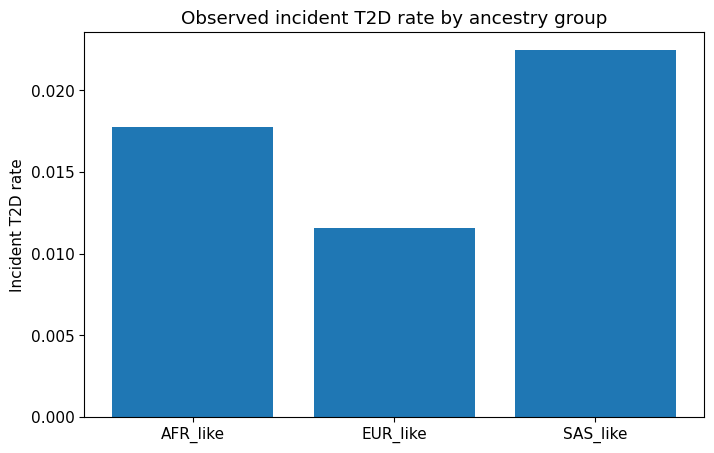

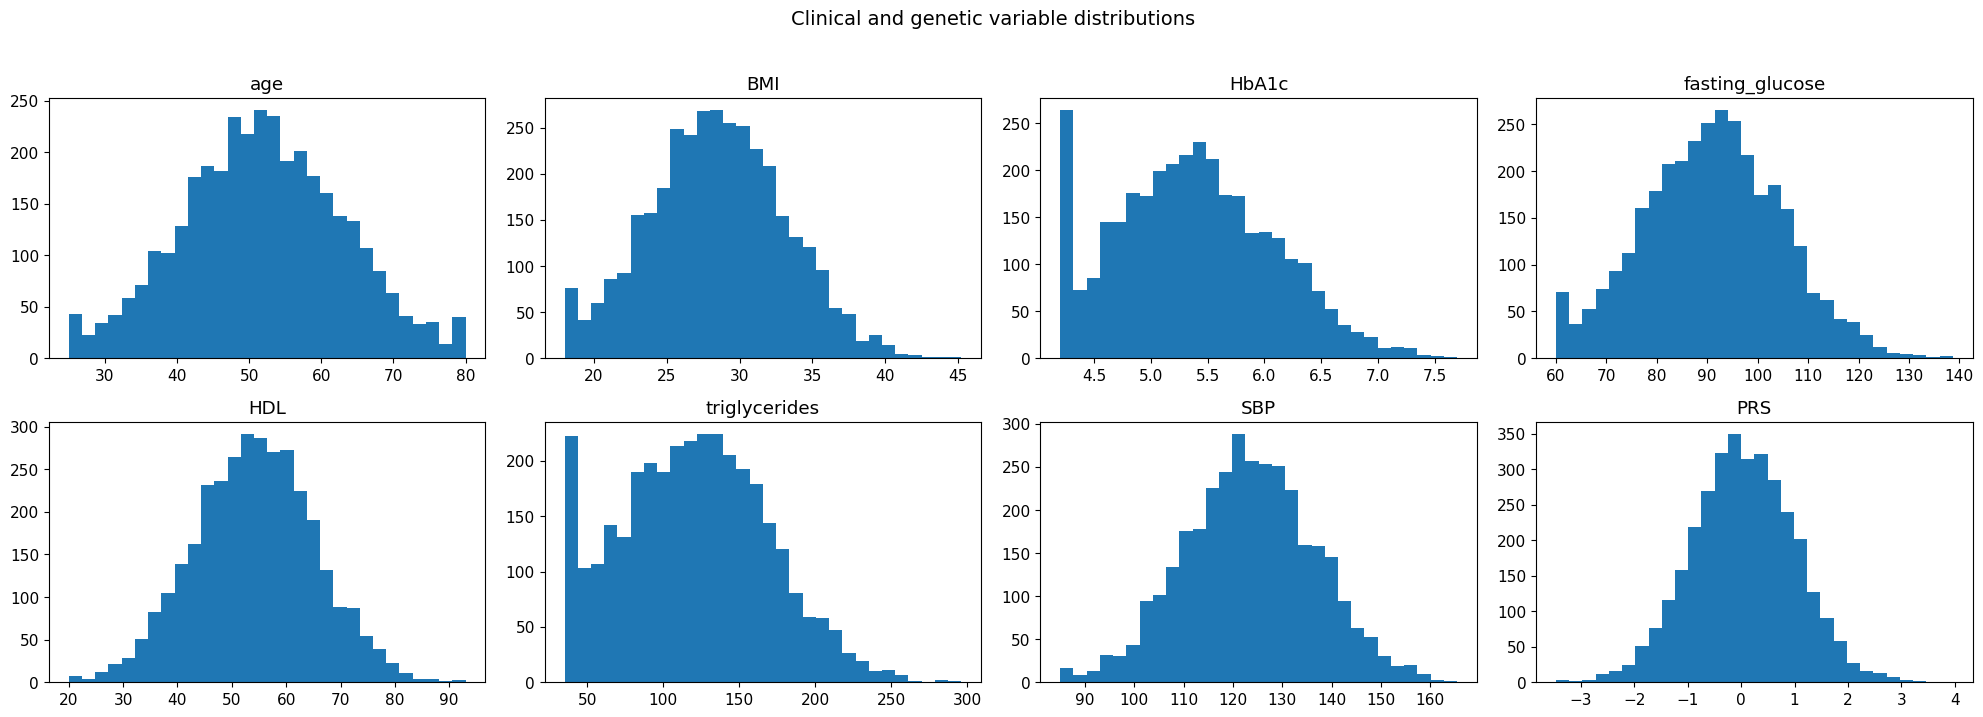

In [10]:

# 3. Quick QC and descriptive analysis

display_cols = [
    "age", "BMI", "HbA1c", "fasting_glucose", "HDL",
    "triglycerides", "SBP", "PRS", "incident_t2d", "time_to_event"
]
desc = base_df[display_cols].describe().T
print(desc)

print("\nMissingness fraction by column, top 20:")
miss = base_df.isna().mean().sort_values(ascending=False)
print(miss.head(20))

summary_ancestry = summarize_by_group(base_df, "ancestry", "incident_t2d")
print("\nIncident disease by ancestry:")
print(summary_ancestry)

plt.figure()
plt.bar(summary_ancestry["ancestry"], summary_ancestry["event_rate"])
plt.ylabel("Incident T2D rate")
plt.title("Observed incident T2D rate by ancestry group")
plt.show()

plot_hist_grid(
    base_df,
    ["age", "BMI", "HbA1c", "fasting_glucose", "HDL", "triglycerides", "SBP", "PRS"],
    ncols=4,
    title="Clinical and genetic variable distributions"
)



### Interpretation

This section checks whether the simulated cohort looks internally coherent.

Key things to inspect:
- whether the continuous variables have plausible ranges,
- whether missingness is modest rather than catastrophic,
- whether event rates are non-trivial,
- whether the ancestry groups differ somewhat, which is useful for testing transportability.

The histograms should show a broad mixture of low- and high-risk individuals rather than a narrow, unrealistic dataset.


BCAA_score: controls mean=0.300, cases mean=2.248
GlycA: controls mean=0.197, cases mean=1.337
ADIPOQ_protein: controls mean=-0.348, cases mean=-2.577
SHBG_protein: controls mean=-3.069, cases mean=-5.042
ACY1_protein: controls mean=0.249, cases mean=2.043


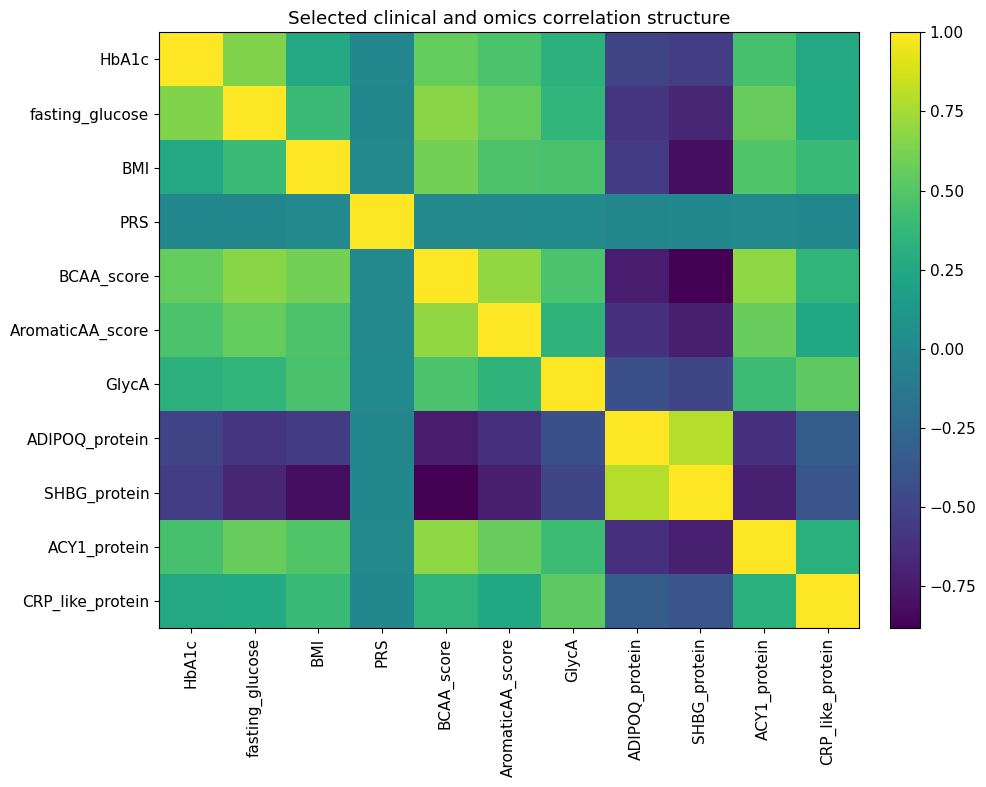

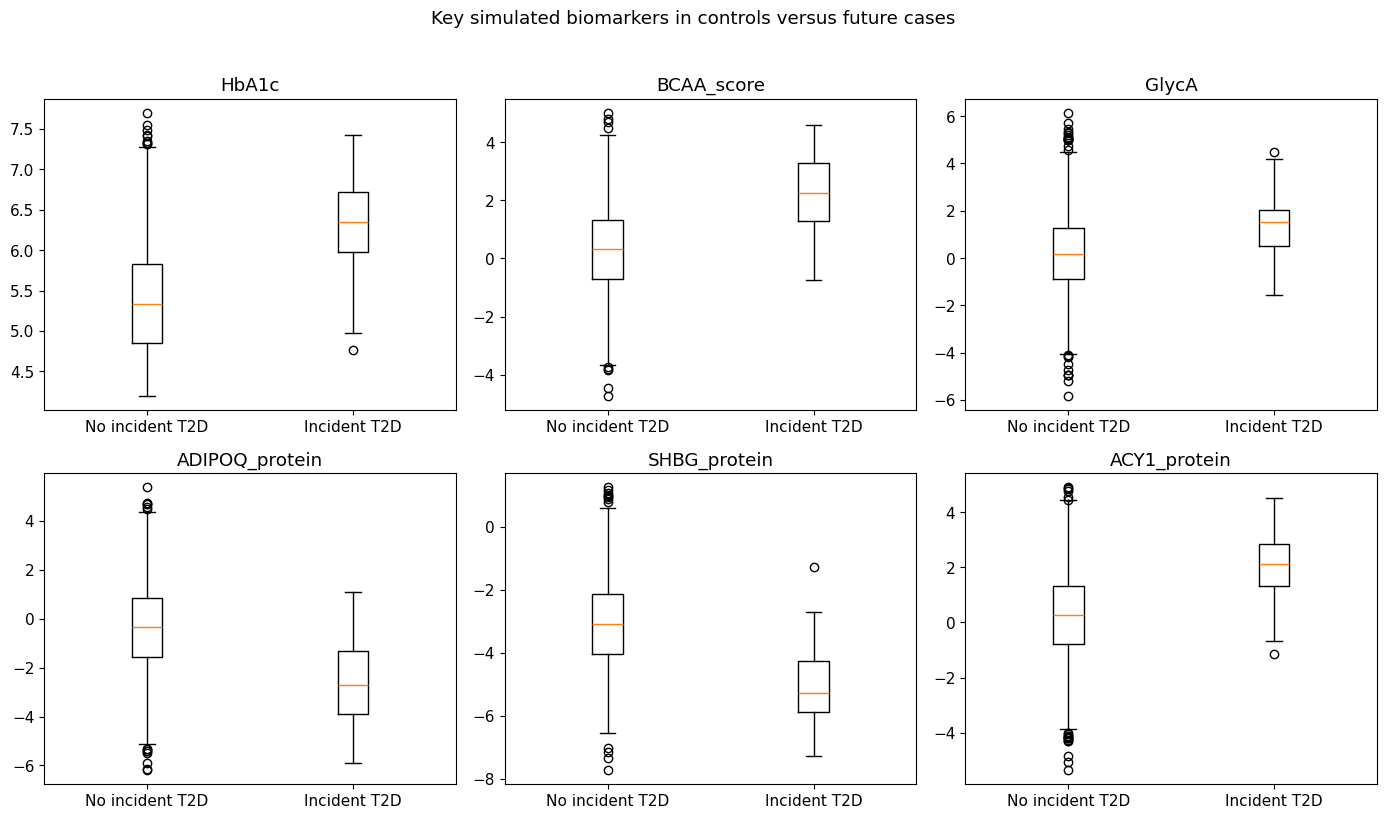

In [13]:

# 4. Exploratory omics biology

base_df["BCAA_score"] = base_df[["Leucine", "Isoleucine", "Valine"]].mean(axis=1)
base_df["AromaticAA_score"] = base_df[["Tyrosine", "Phenylalanine"]].mean(axis=1)

for var in ["BCAA_score", "GlycA", "ADIPOQ_protein", "SHBG_protein", "ACY1_protein"]:
    temp = base_df[[var, "incident_t2d"]].dropna()
    grp = temp.groupby("incident_t2d")[var].mean()
    print(f"{var}: controls mean={grp.get(0, np.nan):.3f}, cases mean={grp.get(1, np.nan):.3f}")

selected_bio = [
    "HbA1c", "fasting_glucose", "BMI", "PRS", "BCAA_score",
    "AromaticAA_score", "GlycA", "ADIPOQ_protein",
    "SHBG_protein", "ACY1_protein", "CRP_like_protein"
]
plot_corr_heatmap(base_df.dropna(subset=selected_bio), selected_bio, title="Selected clinical and omics correlation structure")

case_control_vars = [
    "HbA1c", "BCAA_score", "GlycA", "ADIPOQ_protein", "SHBG_protein", "ACY1_protein"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, var in zip(axes, case_control_vars):
    d0 = base_df.loc[base_df["incident_t2d"] == 0, var].dropna().values
    d1 = base_df.loc[base_df["incident_t2d"] == 1, var].dropna().values
    ax.boxplot([d0, d1], labels=["No incident T2D", "Incident T2D"])
    ax.set_title(var)
for ax in axes[len(case_control_vars):]:
    ax.axis("off")
plt.suptitle("Key simulated biomarkers in controls versus future cases", y=1.02)
plt.tight_layout()
plt.show()



### Interpretation

This step asks whether the simulation reproduces the intended *direction* of disease biology.

You should expect future cases to show:
- higher HbA1c,
- higher BCAA-like signal,
- higher GlycA-like inflammation,
- lower adiponectin-like and SHBG-like proteins,
- higher ACY1-like protein.

The correlation heatmap also helps identify whether the simulated omics features align into sensible metabolic and inflammatory modules.


   trajectory_cluster  event_rate  events     n
0                   1    0.017332      23  1327
1                   2    0.015209      12   789
2                   3    0.013728      19  1384


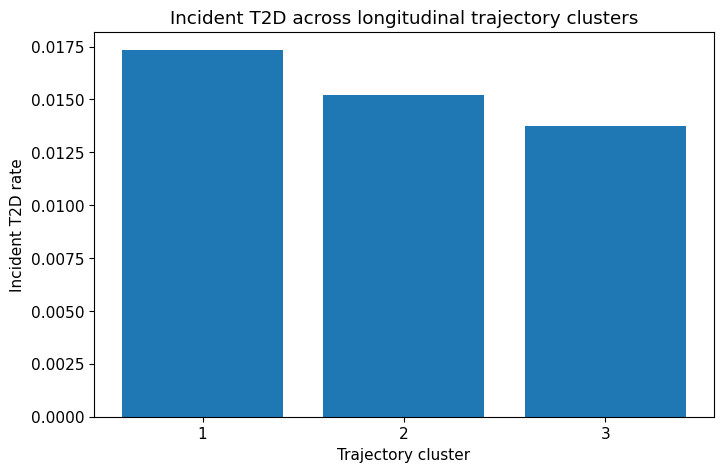

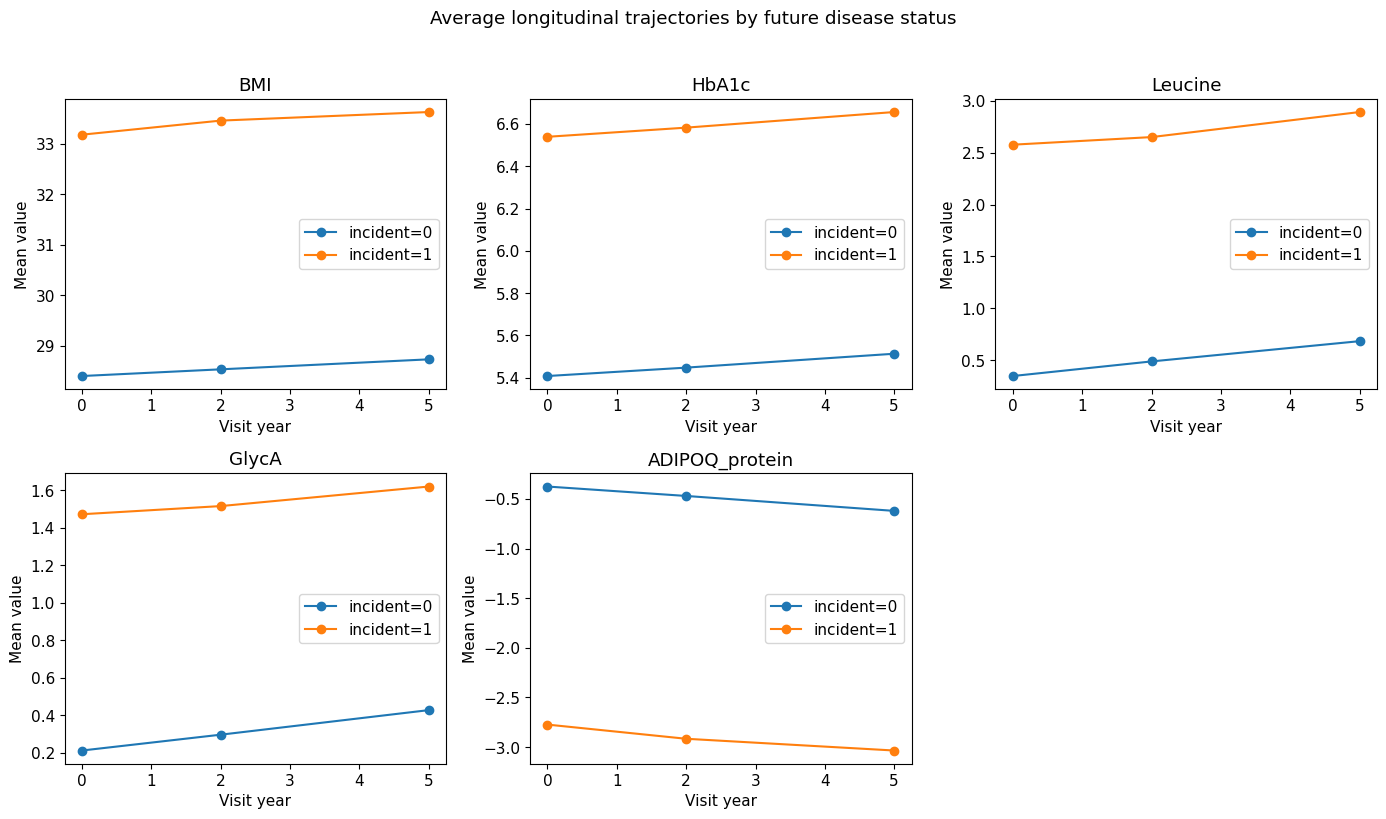

In [15]:

# 5. Longitudinal trajectories

traj = (
    long_df.sort_values(["participant_id", "visit_year"])
    .groupby("participant_id", observed=True)
    .apply(lambda g: pd.Series({
        "BMI_baseline": g.loc[g["visit_year"] == 0, "BMI"].values[0],
        "BMI_slope_per_year": np.polyfit(g["visit_year"], g["BMI"], 1)[0],
        "HbA1c_baseline": g.loc[g["visit_year"] == 0, "HbA1c"].values[0],
        "HbA1c_slope_per_year": np.polyfit(g["visit_year"], g["HbA1c"], 1)[0],
        "Leucine_slope_per_year": np.polyfit(g["visit_year"], g["Leucine"], 1)[0],
        "GlycA_slope_per_year": np.polyfit(g["visit_year"], g["GlycA"], 1)[0],
        "ADIPOQ_slope_per_year": np.polyfit(g["visit_year"], g["ADIPOQ_protein"], 1)[0],
    }))
    .reset_index()
)

base_df = base_df.merge(traj, on="participant_id", how="left")

traj_vars = [
    "BMI_slope_per_year",
    "HbA1c_slope_per_year",
    "Leucine_slope_per_year",
    "GlycA_slope_per_year",
    "ADIPOQ_slope_per_year"
]

traj_cluster_input = zscore_df(base_df[traj_vars].fillna(base_df[traj_vars].median()))
Z = linkage(traj_cluster_input, method="ward")
cluster_labels = fcluster(Z, t=3, criterion="maxclust")
base_df["trajectory_cluster"] = cluster_labels

cluster_event = summarize_by_group(base_df, "trajectory_cluster", "incident_t2d")
print(cluster_event)

plt.figure()
plt.bar(cluster_event["trajectory_cluster"].astype(str), cluster_event["event_rate"])
plt.xlabel("Trajectory cluster")
plt.ylabel("Incident T2D rate")
plt.title("Incident T2D across longitudinal trajectory clusters")
plt.show()

traj_plot_vars = ["BMI", "HbA1c", "Leucine", "GlycA", "ADIPOQ_protein"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

long_with_event = long_df.merge(base_df[["participant_id", "incident_t2d"]], on="participant_id", how="left")

for ax, var in zip(axes, traj_plot_vars):
    means = (
        long_with_event.groupby(["incident_t2d", "visit_year"], observed=True)[var]
        .mean()
        .reset_index()
    )
    for label, g in means.groupby("incident_t2d", observed=True):
        ax.plot(g["visit_year"], g[var], marker="o", label=f"incident={label}")
    ax.set_title(var)
    ax.set_xlabel("Visit year")
    ax.set_ylabel("Mean value")
    ax.legend()

axes[-1].axis("off")
plt.suptitle("Average longitudinal trajectories by future disease status", y=1.02)
plt.tight_layout()
plt.show()



### Interpretation

This section converts repeated measurements into **trajectory features**.

That matters because many disease-prediction problems are not only about where someone starts, but also about:
- whether they are drifting upward or downward,
- how quickly biomarkers are changing,
- whether several risk signals worsen together.

The cluster analysis groups people by the *shape* of their trajectories. If one cluster shows much higher event rates, that suggests the model can learn disease-relevant temporal patterns rather than only static baseline risk.


Explained variance ratio first 10 PCs:
[0.2958 0.0594 0.0301 0.0182 0.0178 0.0174 0.0173 0.0169 0.0165 0.0164]


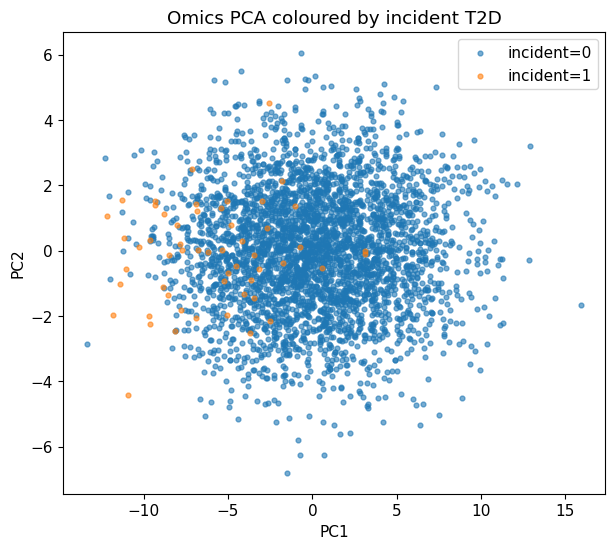

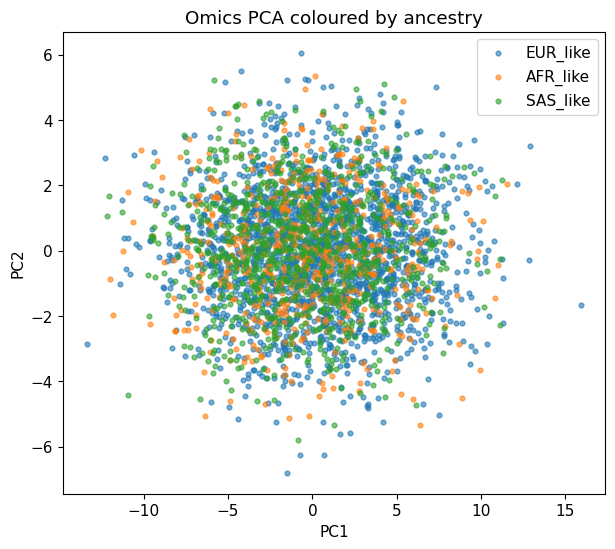

   omics_subtype  event_rate  events     n
0              1    0.001192       1   839
1              2    0.052425      40   763
2              3    0.004785       5  1045
3              4    0.009379       8   853


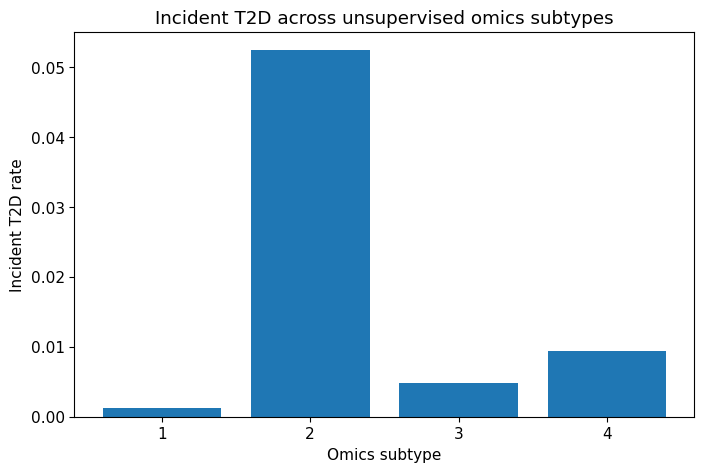

In [19]:

# 6. Dimensionality reduction and subtype discovery

omics_for_pca = tx_cols + prot_cols + met_cols
omics_mat = base_df[omics_for_pca].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_omics_imp = imputer.fit_transform(omics_mat)
X_omics_scaled = scaler.fit_transform(X_omics_imp)

pca = PCA(n_components=10, random_state=42)
pcs = pca.fit_transform(X_omics_scaled)

pca_df = pd.DataFrame(pcs[:, :3], columns=["PC1", "PC2", "PC3"])
pca_df["incident_t2d"] = base_df["incident_t2d"].values
pca_df["ancestry"] = base_df["ancestry"].values
pca_df["trajectory_cluster"] = base_df["trajectory_cluster"].values

print("Explained variance ratio first 10 PCs:")
print(np.round(pca.explained_variance_ratio_, 4))

plt.figure(figsize=(7, 6))
for label in sorted(pca_df["incident_t2d"].unique()):
    g = pca_df[pca_df["incident_t2d"] == label]
    plt.scatter(g["PC1"], g["PC2"], s=12, alpha=0.6, label=f"incident={label}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Omics PCA coloured by incident T2D")
plt.legend()
plt.show()

plt.figure(figsize=(7, 6))
for label in pca_df["ancestry"].unique():
    g = pca_df[pca_df["ancestry"] == label]
    plt.scatter(g["PC1"], g["PC2"], s=12, alpha=0.6, label=label)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Omics PCA coloured by ancestry")
plt.legend()
plt.show()

Z_pca = linkage(pcs[:, :5], method="ward")
subtypes = fcluster(Z_pca, t=4, criterion="maxclust")
base_df["omics_subtype"] = subtypes

subtype_table = summarize_by_group(base_df, "omics_subtype", "incident_t2d")
print(subtype_table)

plt.figure()
plt.bar(subtype_table["omics_subtype"].astype(str), subtype_table["event_rate"])
plt.xlabel("Omics subtype")
plt.ylabel("Incident T2D rate")
plt.title("Incident T2D across unsupervised omics subtypes")
plt.show()



### Interpretation

The omics space is high-dimensional, so PCA provides a compact view of dominant variation.

This is useful for two reasons:
- it shows whether disease cases separate at least partially from non-cases,
- it reveals whether hidden structure such as ancestry or technical variation may influence the embedding.

The unsupervised subtype step asks a more biological question:
do there appear to be different **molecular routes** to future diabetes?

If some unsupervised subtypes have higher event rates, that suggests the disease can be represented as a set of latent molecular states.


             feature  odds_ratio_per_unit    ci_low    ci_high       p_value
2              HbA1c             7.576526  4.911713  11.687112  5.324848e-20
8         BCAA_score             2.894407  2.303806   3.636413  7.022676e-20
12      SHBG_protein             0.299949  0.231044   0.389404  1.534301e-19
11    ADIPOQ_protein             0.458750  0.384166   0.547813  7.439978e-18
3    fasting_glucose             1.099066  1.075353   1.123301  2.099414e-17
13      ACY1_protein             2.342507  1.900146   2.887851  1.567615e-15
9   AromaticAA_score             2.971932  2.265301   3.898987  3.753005e-15
14     GFRA1_protein             2.443905  1.938626   3.080879  3.978975e-14
1                BMI             1.259315  1.184439   1.338925  1.678368e-13
0                age             1.094226  1.066143   1.123050  1.136776e-11
5      triglycerides             1.019520  1.013474   1.025603  1.893079e-10
16  IL6_like_protein             1.853158  1.530067   2.244475  2.770197e-10

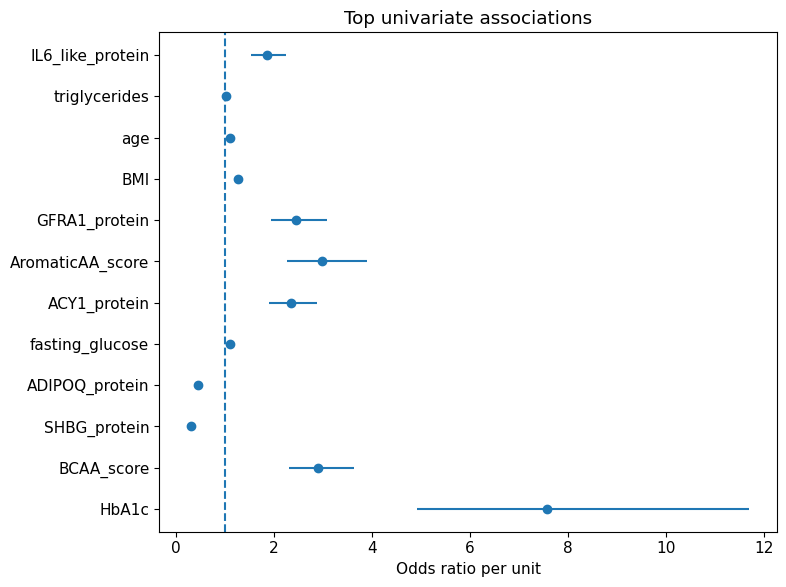

In [21]:

# 7. Univariate associations

candidate_vars = [
    "age", "BMI", "HbA1c", "fasting_glucose", "HDL", "triglycerides", "SBP", "PRS",
    "BCAA_score", "AromaticAA_score", "GlycA",
    "ADIPOQ_protein", "SHBG_protein", "ACY1_protein", "GFRA1_protein",
    "CRP_like_protein", "IL6_like_protein"
]

uni_results = []
for var in candidate_vars:
    temp = base_df[[var, "incident_t2d"]].dropna()
    if HAS_STATSMODELS:
        X = sm.add_constant(temp[[var]])
        y = temp["incident_t2d"]
        model = sm.Logit(y, X).fit(disp=False)
        coef = model.params[var]
        pval = model.pvalues[var]
        or_ = np.exp(coef)
        ci_low, ci_high = np.exp(model.conf_int().loc[var].values)
    else:
        r, pval = stats.pointbiserialr(temp["incident_t2d"], temp[var])
        or_, ci_low, ci_high = np.nan, np.nan, np.nan
    uni_results.append({
        "feature": var,
        "odds_ratio_per_unit": or_,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": pval
    })

uni_df = pd.DataFrame(uni_results).sort_values("p_value")
print(uni_df.head(15))

top_uni = uni_df.dropna().head(12).copy()
plt.figure(figsize=(8, 6))
ypos = np.arange(len(top_uni))
plt.errorbar(
    x=top_uni["odds_ratio_per_unit"],
    y=ypos,
    xerr=[
        top_uni["odds_ratio_per_unit"] - top_uni["ci_low"],
        top_uni["ci_high"] - top_uni["odds_ratio_per_unit"]
    ],
    fmt="o"
)
plt.axvline(1.0, linestyle="--")
plt.yticks(ypos, top_uni["feature"])
plt.xlabel("Odds ratio per unit")
plt.title("Top univariate associations")
plt.tight_layout()
plt.show()



### Interpretation

Univariate association screening is not a substitute for multivariable modelling, but it is still useful.

It helps answer:
- which features show the strongest single-feature relationship with future disease,
- whether the simulated directions match the intended biology,
- whether there are obvious candidates for downstream prioritisation.

In a real study, you would usually correct for multiple testing and then compare these results with multivariable and penalised models.


Running Clinical ...
Running Clinical+PRS ...
Running Clinical+Metabolites ...
Running Clinical+Proteins ...
Running Clinical+MultiOmics ...
Running Clinical+MultiOmics+Trajectory ...

Cross-validated predictive performance:
                                AUROC  AUPRC  Brier  Accuracy     F1    ECE  \
Clinical                        0.793  0.070  0.256     0.714  0.077  0.289   
Clinical+PRS                    0.759  0.093  0.224     0.752  0.075  0.247   
Clinical+MultiOmics             0.743  0.065  0.157     0.831  0.092  0.168   
Clinical+MultiOmics+Trajectory  0.740  0.063  0.146     0.841  0.083  0.157   
Clinical+Proteins               0.719  0.085  0.231     0.746  0.075  0.257   
Clinical+Metabolites            0.614  0.058  0.145     0.830  0.066  0.170   

                                AUROC_95CI_low  AUROC_95CI_high  
Clinical                                 0.738            0.846  
Clinical+PRS                             0.689            0.832  
Clinical+MultiOmics    

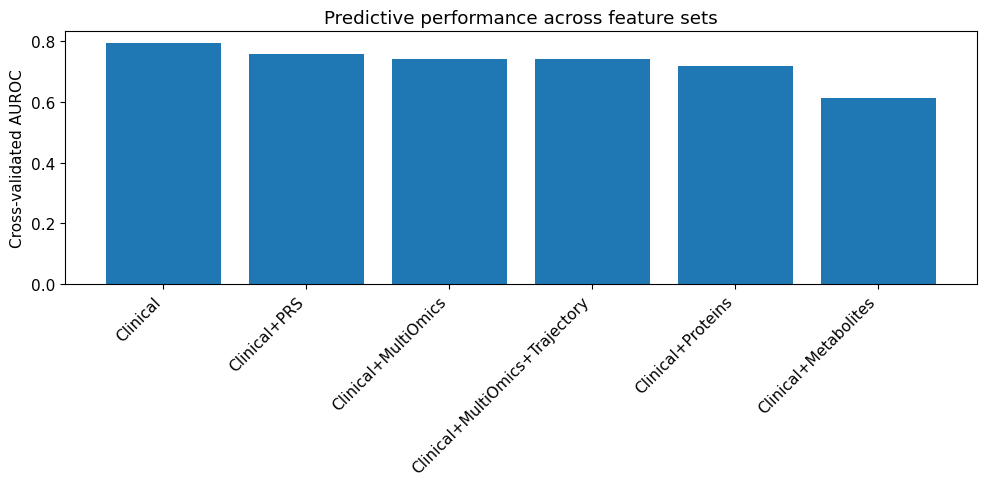

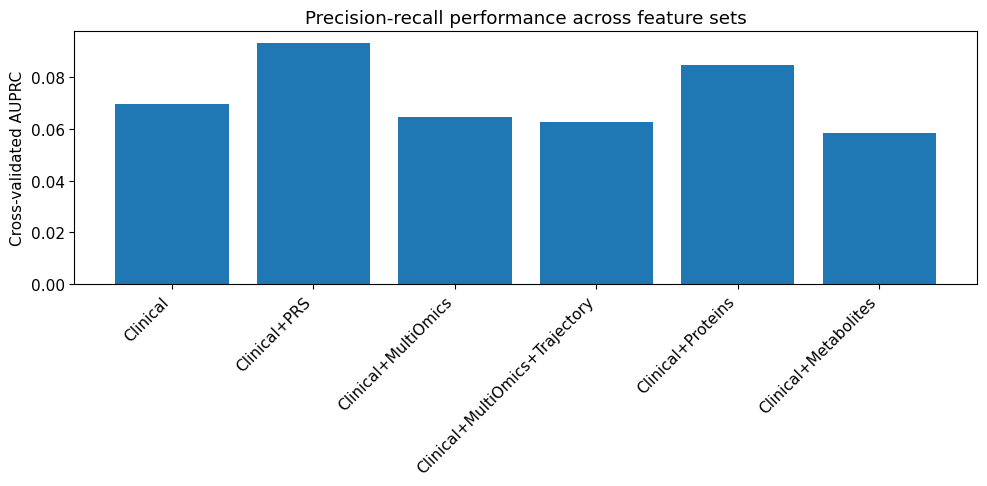

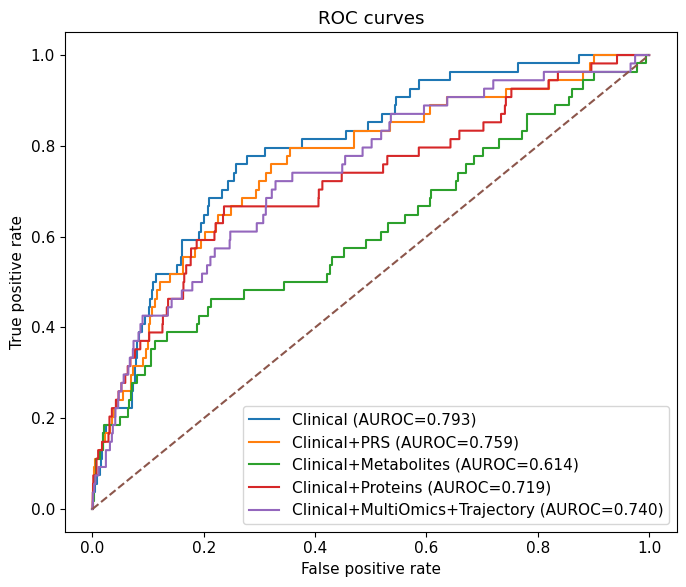

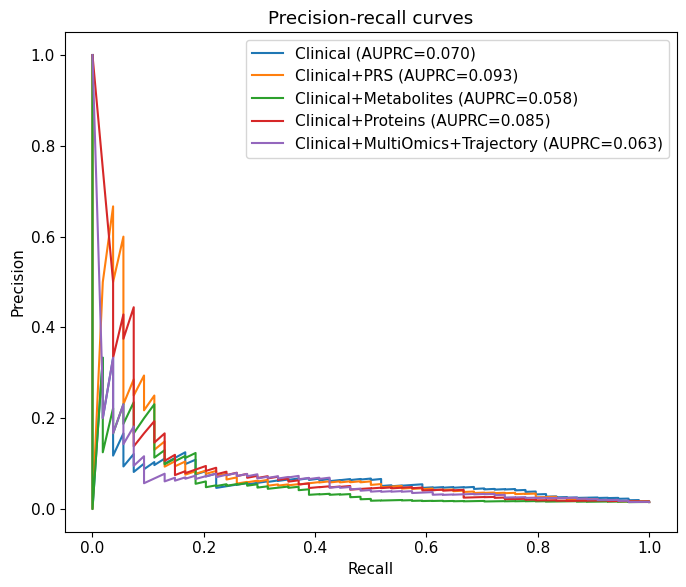

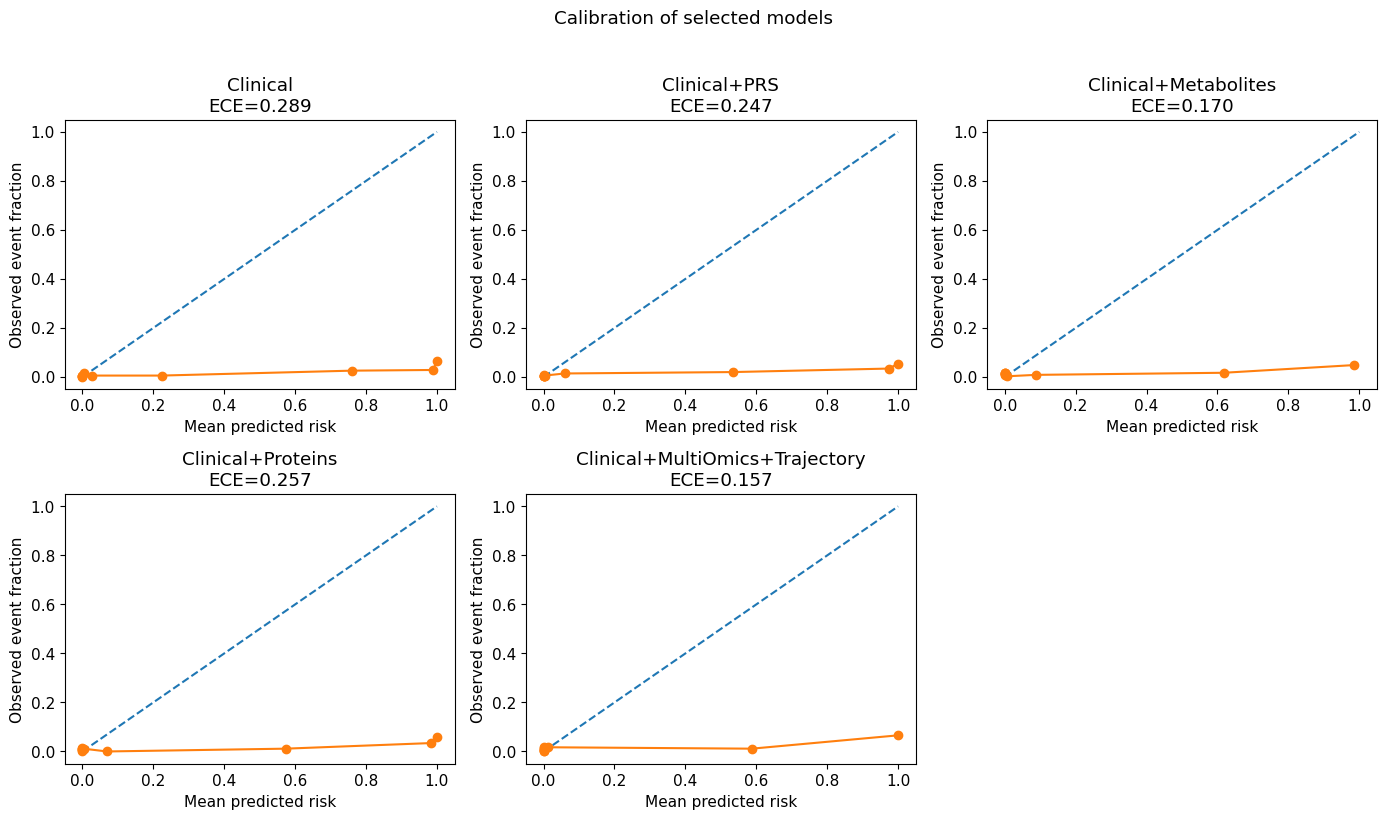

In [23]:

# 8. Predictive modelling

clinical_features = [
    "age", "sex_male", "BMI", "smoking", "physical_activity",
    "family_history", "HbA1c", "fasting_glucose", "HDL", "triglycerides", "SBP"
]
genetic_features = ["PRS"]
proteomic_features = prot_cols
metabolomic_features = met_cols
transcript_features = tx_cols
trajectory_features = traj_vars + ["trajectory_cluster"]

df_model = base_df.copy()
df_model = pd.get_dummies(df_model, columns=["ancestry"], drop_first=True)
ancestry_dummy_cols = [c for c in df_model.columns if c.startswith("ancestry_")]

feature_sets = {
    "Clinical": clinical_features + ancestry_dummy_cols,
    "Clinical+PRS": clinical_features + genetic_features + ancestry_dummy_cols,
    "Clinical+Metabolites": clinical_features + metabolomic_features + ancestry_dummy_cols,
    "Clinical+Proteins": clinical_features + proteomic_features + ancestry_dummy_cols,
    "Clinical+MultiOmics": clinical_features + genetic_features + metabolomic_features + proteomic_features + transcript_features + ancestry_dummy_cols,
    "Clinical+MultiOmics+Trajectory": clinical_features + genetic_features + metabolomic_features + proteomic_features + transcript_features + trajectory_features + ancestry_dummy_cols
}

target = "incident_t2d"

def evaluate_model_cv(df, feature_list, y_col, n_splits=5, random_state=42):
    X = df[feature_list]
    y = df[y_col].values

    estimator = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.2,
        max_iter=4000,
        class_weight="balanced",
        random_state=random_state
    )

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator)
    ])

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    prob = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    pred = (prob >= 0.5).astype(int)

    auc = roc_auc_score(y, prob)
    ap = average_precision_score(y, prob)
    brier = brier_score_loss(y, prob)
    acc = accuracy_score(y, pred)
    f1 = f1_score(y, pred)

    ece, cal = expected_calibration_error(y, prob, n_bins=10)
    auc_mean, auc_lo, auc_hi = auc_ci_bootstrap(y, prob, n_boot=300, seed=random_state)
    ap_mean, ap_lo, ap_hi = pr_ci_bootstrap(y, prob, n_boot=300, seed=random_state)

    return {
        "prob": prob,
        "pred": pred,
        "auc": auc,
        "ap": ap,
        "brier": brier,
        "acc": acc,
        "f1": f1,
        "ece": ece,
        "calibration": cal,
        "auc_ci": (auc_mean, auc_lo, auc_hi),
        "ap_ci": (ap_mean, ap_lo, ap_hi),
        "pipeline": pipe
    }

results = {}
for name, feats in feature_sets.items():
    print(f"Running {name} ...")
    results[name] = evaluate_model_cv(df_model, feats, target, n_splits=5)

perf_table = pd.DataFrame({
    name: {
        "AUROC": results[name]["auc"],
        "AUPRC": results[name]["ap"],
        "Brier": results[name]["brier"],
        "Accuracy": results[name]["acc"],
        "F1": results[name]["f1"],
        "ECE": results[name]["ece"],
        "AUROC_95CI_low": results[name]["auc_ci"][1],
        "AUROC_95CI_high": results[name]["auc_ci"][2]
    }
    for name in results
}).T.sort_values("AUROC", ascending=False)

print("\nCross-validated predictive performance:")
print(perf_table.round(3))

plt.figure(figsize=(10, 5))
plt.bar(perf_table.index, perf_table["AUROC"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cross-validated AUROC")
plt.title("Predictive performance across feature sets")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(perf_table.index, perf_table["AUPRC"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cross-validated AUPRC")
plt.title("Precision-recall performance across feature sets")
plt.tight_layout()
plt.show()

selected_models = ["Clinical", "Clinical+PRS", "Clinical+Metabolites", "Clinical+Proteins", "Clinical+MultiOmics+Trajectory"]

plt.figure(figsize=(7, 6))
y_true = df_model[target].values
for name in selected_models:
    fpr, tpr, _ = roc_curve(y_true, results[name]["prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUROC={results[name]['auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
for name in selected_models:
    prec, rec, _ = precision_recall_curve(y_true, results[name]["prob"])
    plt.plot(rec, prec, label=f"{name} (AUPRC={results[name]['ap']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves")
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, name in zip(axes, selected_models):
    cal = results[name]["calibration"]
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(cal["mean_pred"], cal["frac_pos"], marker="o")
    ax.set_title(f"{name}\nECE={results[name]['ece']:.3f}")
    ax.set_xlabel("Mean predicted risk")
    ax.set_ylabel("Observed event fraction")
for ax in axes[len(selected_models):]:
    ax.axis("off")
plt.suptitle("Calibration of selected models", y=1.02)
plt.tight_layout()
plt.show()



### Interpretation

This is the central predictive comparison.

The feature sets are deliberately nested:
- **Clinical** is the baseline benchmark.
- **Clinical+PRS** tests how much polygenic information helps.
- **Clinical+Metabolites** and **Clinical+Proteins** test single-omic extensions.
- **Clinical+MultiOmics** tests broader integration.
- **Clinical+MultiOmics+Trajectory** adds longitudinal summary information.

The main questions are:
- Does multi-omics improve prediction over clinical data alone?
- Is the gain modest or substantial?
- Does calibration remain acceptable as model complexity increases?

A realistic result in this synthetic setup is that multi-omics improves performance, but not infinitely. Clinical factors remain strong anchors.


Best feature set: Clinical
Holdout AUROC: 0.859
Holdout AUPRC: 0.177
Holdout Brier: 0.23
Holdout F1: 0.081


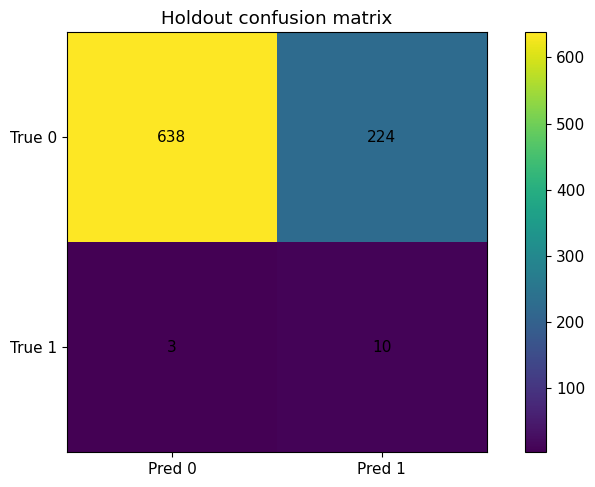


Top 25 absolute coefficients:
              feature  coefficient
0               HbA1c     3.772470
1     fasting_glucose     3.096614
2                 BMI     2.794637
3      family_history    -2.125402
4   ancestry_SAS_like    -1.550552
5                 age    -1.106966
6                 SBP     1.091533
7   ancestry_EUR_like    -0.820108
8   physical_activity     0.766815
9       triglycerides     0.476397
10                HDL    -0.342140
11            smoking     0.240760
12           sex_male    -0.193854


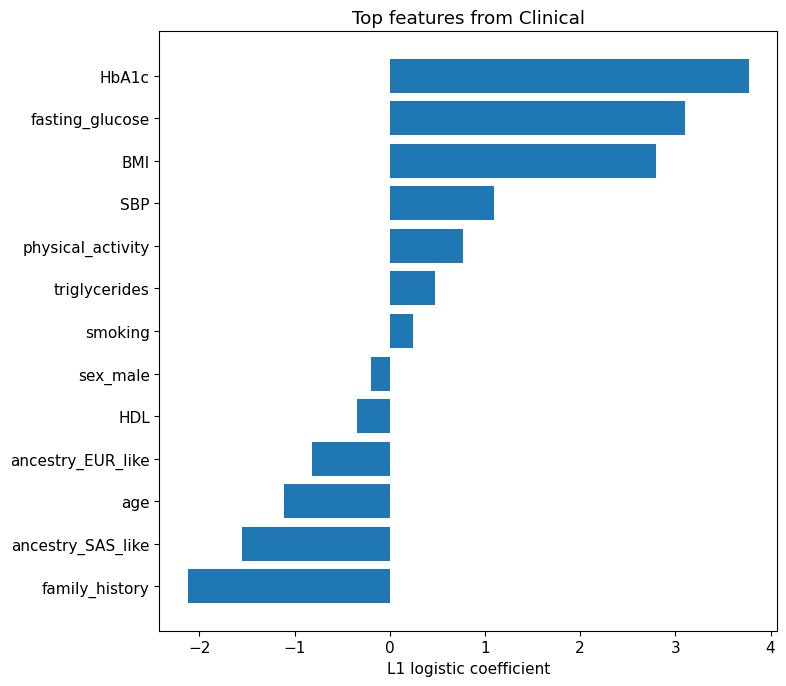


Top permutation importance features:
              feature  importance_mean  importance_std
6               HbA1c         0.126870        0.056335
7     fasting_glucose         0.062324        0.027003
2                 BMI         0.024112        0.027115
11  ancestry_EUR_like         0.015376        0.006005
10                SBP         0.014787        0.007862
8                 HDL        -0.000473        0.002429
9       triglycerides        -0.000812        0.003078
1            sex_male        -0.000973        0.001593
3             smoking        -0.002722        0.001954
4   physical_activity        -0.003980        0.005088
0                 age        -0.012154        0.012629
5      family_history        -0.017544        0.014299
12  ancestry_SAS_like        -0.033339        0.009004


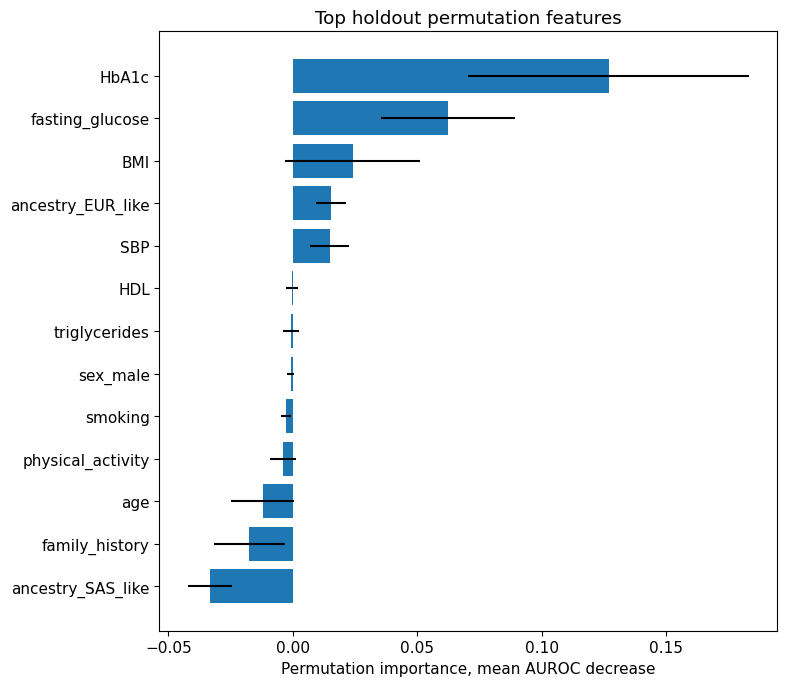

In [26]:

# 9. Holdout fit for interpretation

best_name = perf_table.index[0]
best_feats = feature_sets[best_name]

X = df_model[best_feats]
y = df_model[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

best_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.2,
        max_iter=4000,
        class_weight="balanced",
        random_state=42
    ))
])

best_pipe.fit(X_train, y_train)
test_prob = best_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

print("Best feature set:", best_name)
print("Holdout AUROC:", round(roc_auc_score(y_test, test_prob), 3))
print("Holdout AUPRC:", round(average_precision_score(y_test, test_prob), 3))
print("Holdout Brier:", round(brier_score_loss(y_test, test_prob), 3))
print("Holdout F1:", round(f1_score(y_test, test_pred), 3))

cm = confusion_matrix(y_test, test_pred)
plt.figure()
plt.imshow(cm)
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.title("Holdout confusion matrix")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

coefs = pd.Series(best_pipe.named_steps["model"].coef_[0], index=best_feats)
coef_df = coefs.sort_values(key=np.abs, ascending=False).reset_index()
coef_df.columns = ["feature", "coefficient"]
print("\nTop 25 absolute coefficients:")
print(coef_df.head(25))

plt.figure(figsize=(8, 7))
top_coef = coef_df.head(20).sort_values("coefficient")
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.xlabel("L1 logistic coefficient")
plt.title(f"Top features from {best_name}")
plt.tight_layout()
plt.show()

perm = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=10, random_state=42, scoring="roc_auc"
)
perm_df = pd.DataFrame({
    "feature": best_feats,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop permutation importance features:")
print(perm_df.head(20))

plt.figure(figsize=(8, 7))
top_perm = perm_df.head(20).sort_values("importance_mean")
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
plt.xlabel("Permutation importance, mean AUROC decrease")
plt.title("Top holdout permutation features")
plt.tight_layout()
plt.show()



### Interpretation

Cross-validation tells us how the models compare overall, but a separate holdout fit is helpful for interpretation.

This section provides:
- a clean train/test estimate,
- a confusion matrix,
- sparse logistic coefficients,
- permutation importance.

The coefficient plot shows which features the penalised model keeps.
The permutation plot shows which features matter most to actual predictive performance on unseen data.

In a real project, the overlap between these two rankings is often informative:
stable agreement suggests robust signal, while disagreement may indicate collinearity or feature substitution.


        group    n  event_rate  AUROC  AUPRC  Brier
0    EUR_like  651       0.009  0.956  0.115  0.240
3  sex_male=1  423       0.019  0.859  0.128  0.246
2  sex_male=0  452       0.011  0.858  0.273  0.215
1    SAS_like  224       0.031  0.801  0.263  0.201


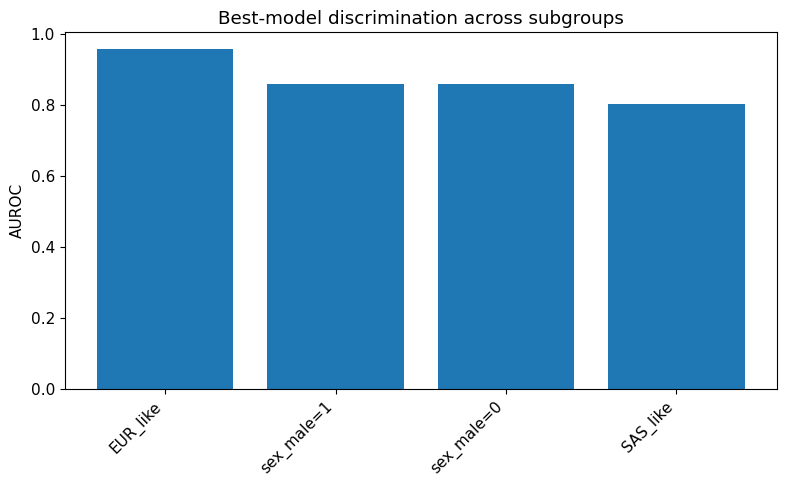

In [30]:

# 10. Subgroup fairness and transportability analysis

test_meta = X_test.copy()
test_meta["y_true"] = y_test
test_meta["y_prob"] = test_prob

def recover_ancestry(row):
    if "ancestry_SAS_like" in row.index and row["ancestry_SAS_like"] == 1:
        return "SAS_like"
    elif "ancestry_AFR_like" in row.index and row["ancestry_AFR_like"] == 1:
        return "AFR_like"
    else:
        return "EUR_like"

if "ancestry_SAS_like" in test_meta.columns or "ancestry_AFR_like" in test_meta.columns:
    test_meta["ancestry_label"] = test_meta.apply(recover_ancestry, axis=1)
else:
    test_meta["ancestry_label"] = "Unknown"

subgroup_rows = []
for grp, g in test_meta.groupby("ancestry_label", observed=True):
    if g["y_true"].nunique() < 2:
        continue
    subgroup_rows.append({
        "group": grp,
        "n": len(g),
        "event_rate": g["y_true"].mean(),
        "AUROC": roc_auc_score(g["y_true"], g["y_prob"]),
        "AUPRC": average_precision_score(g["y_true"], g["y_prob"]),
        "Brier": brier_score_loss(g["y_true"], g["y_prob"])
    })

for grp, g in test_meta.groupby("sex_male", observed=True):
    if g["y_true"].nunique() < 2:
        continue
    subgroup_rows.append({
        "group": f"sex_male={grp}",
        "n": len(g),
        "event_rate": g["y_true"].mean(),
        "AUROC": roc_auc_score(g["y_true"], g["y_prob"]),
        "AUPRC": average_precision_score(g["y_true"], g["y_prob"]),
        "Brier": brier_score_loss(g["y_true"], g["y_prob"])
    })

subgroup_df = pd.DataFrame(subgroup_rows).sort_values("AUROC", ascending=False)
print(subgroup_df.round(3))

plt.figure(figsize=(8, 5))
plt.bar(subgroup_df["group"], subgroup_df["AUROC"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("AUROC")
plt.title("Best-model discrimination across subgroups")
plt.tight_layout()
plt.show()



### Interpretation

This section explicitly tests whether model performance is similar across subgroups.

That matters because a model can look good overall while performing worse in specific populations.

Here, subgroup evaluation is not intended as a definitive fairness analysis. It is a **stress test** showing how to examine:
- event-rate differences,
- discrimination differences,
- calibration or error differences across groups.

In a real human-genetics programme, this kind of analysis is essential for assessing **transferability and equity**.


   risk_decile  event_rate  events    n
0            1    0.000000       0  350
1            2    0.002857       1  350
2            3    0.002857       1  350
3            4    0.002857       1  350
4            5    0.014286       5  350
5            6    0.005714       2  350
6            7    0.005714       2  350
7            8    0.025714       9  350
8            9    0.028571      10  350
9           10    0.065714      23  350


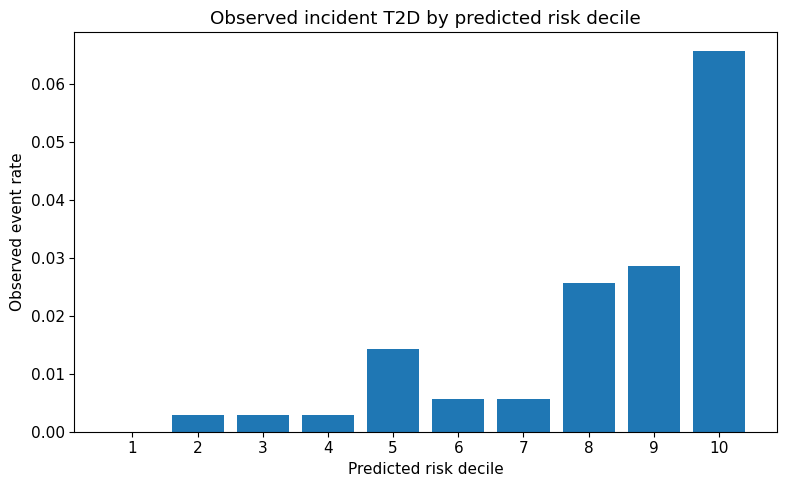

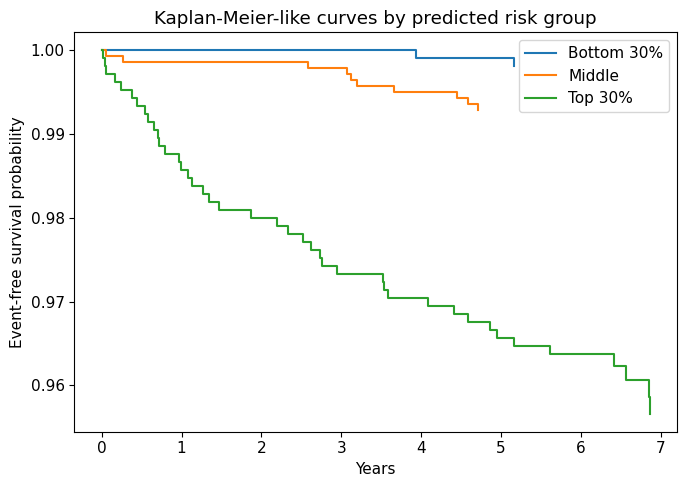

In [32]:

# 11. Risk stratification and Kaplan-Meier-like curves

base_df["cv_risk_best"] = results[best_name]["prob"]
base_df["risk_decile"] = pd.qcut(base_df["cv_risk_best"], 10, labels=False) + 1

risk_decile_event = summarize_by_group(base_df, "risk_decile", "incident_t2d")
print(risk_decile_event)

plt.figure()
plt.bar(risk_decile_event["risk_decile"].astype(str), risk_decile_event["event_rate"])
plt.xlabel("Predicted risk decile")
plt.ylabel("Observed event rate")
plt.title("Observed incident T2D by predicted risk decile")
plt.tight_layout()
plt.show()

base_df["risk_group"] = np.where(
    base_df["risk_decile"] >= 8, "Top 30%",
    np.where(base_df["risk_decile"] <= 3, "Bottom 30%", "Middle")
)

plt.figure(figsize=(7, 5))
for grp in ["Bottom 30%", "Middle", "Top 30%"]:
    g = base_df[base_df["risk_group"] == grp]
    t, s = km_curve(g["time_to_event"].values, g["incident_t2d"].values)
    plt.step(t, s, where="post", label=grp)
plt.xlabel("Years")
plt.ylabel("Event-free survival probability")
plt.title("Kaplan-Meier-like curves by predicted risk group")
plt.legend()
plt.tight_layout()
plt.show()



### Interpretation

A useful disease-prediction model should not only separate cases and controls statistically, it should also create meaningful **risk strata**.

The decile analysis asks:
- do observed event rates rise across predicted-risk groups?
- is there monotonic enrichment of future disease in the top deciles?

The Kaplan-Meier-like plot reframes the same result over time.
If the high-risk group loses event-free survival earlier, the model is capturing temporal risk separation rather than only point classification.


          feature_1        feature_2  spearman_r     abs_r
31       BCAA_score     SHBG_protein   -0.851828  0.851828
36       BCAA_score           Valine    0.839979  0.839979
35       BCAA_score          Leucine    0.839756  0.839756
54   ADIPOQ_protein     SHBG_protein    0.738066  0.738066
68     SHBG_protein          Leucine   -0.724590  0.724590
69     SHBG_protein           Valine   -0.713218  0.713218
30       BCAA_score   ADIPOQ_protein   -0.710155  0.710155
65     SHBG_protein     ACY1_protein   -0.675313  0.675313
32       BCAA_score     ACY1_protein    0.654078  0.654078
18  fasting_glucose     SHBG_protein   -0.636558  0.636558
15  fasting_glucose       BCAA_score    0.631897  0.631897
58   ADIPOQ_protein          Leucine   -0.604079  0.604079
0             HbA1c  fasting_glucose    0.602711  0.602711
59   ADIPOQ_protein           Valine   -0.596844  0.596844
70     SHBG_protein         Tyrosine   -0.586668  0.586668
99          Leucine           Valine    0.581880  0.5818

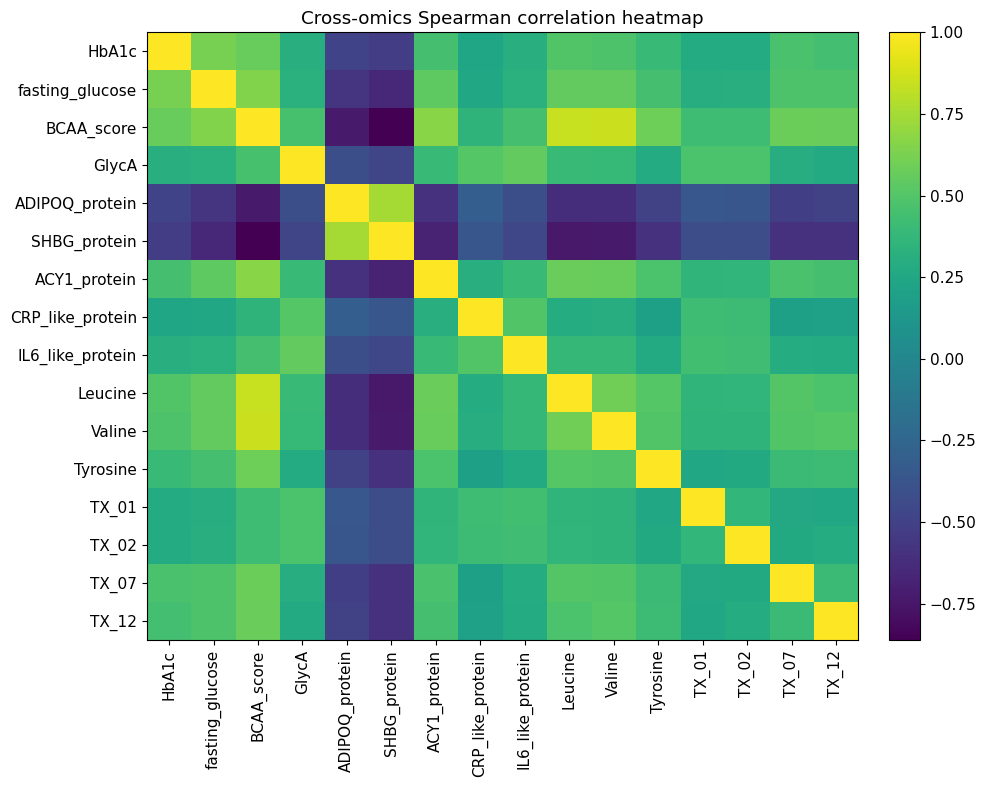

In [34]:

# 12. Cross-omics association network, top correlations

network_features = [
    "HbA1c", "fasting_glucose", "BCAA_score", "GlycA",
    "ADIPOQ_protein", "SHBG_protein", "ACY1_protein",
    "CRP_like_protein", "IL6_like_protein",
    "Leucine", "Valine", "Tyrosine",
    "TX_01", "TX_02", "TX_07", "TX_12"
]

net_df = base_df[network_features].copy()
net_df = net_df.fillna(net_df.median(numeric_only=True))

corrs = net_df.corr(method="spearman")
pairs = []
cols = corrs.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corrs.iloc[i, j]
        pairs.append((cols[i], cols[j], val))

pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "spearman_r"])
pairs_df["abs_r"] = pairs_df["spearman_r"].abs()
top_pairs = pairs_df.sort_values("abs_r", ascending=False).head(20)
print(top_pairs)

plot_corr_heatmap(net_df, net_df.columns.tolist(), title="Cross-omics Spearman correlation heatmap")



### Interpretation

This section gives a compact view of how selected clinical and omics features co-vary.

The strongest correlations often reveal:
- shared biological modules,
- redundancy between candidate predictors,
- possible mechanistic pathways,
- or confounding by a broader latent process such as insulin resistance or inflammation.

This is not a causal network. It is a descriptive association map that helps guide downstream prioritisation.


                 feature  selection_frequency
0                    age                  1.0
12            BCAA_score                  1.0
21    BMI_slope_per_year                  1.0
20      IL6_like_protein                  1.0
19      CRP_like_protein                  1.0
18         GFRA1_protein                  1.0
17          ACY1_protein                  1.0
16          SHBG_protein                  1.0
15        ADIPOQ_protein                  1.0
14                 GlycA                  1.0
13      AromaticAA_score                  1.0
11                   PRS                  1.0
1               sex_male                  1.0
10                   SBP                  1.0
9          triglycerides                  1.0
8                    HDL                  1.0
7        fasting_glucose                  1.0
6                  HbA1c                  1.0
5         family_history                  1.0
4      physical_activity                  1.0
3                smoking          

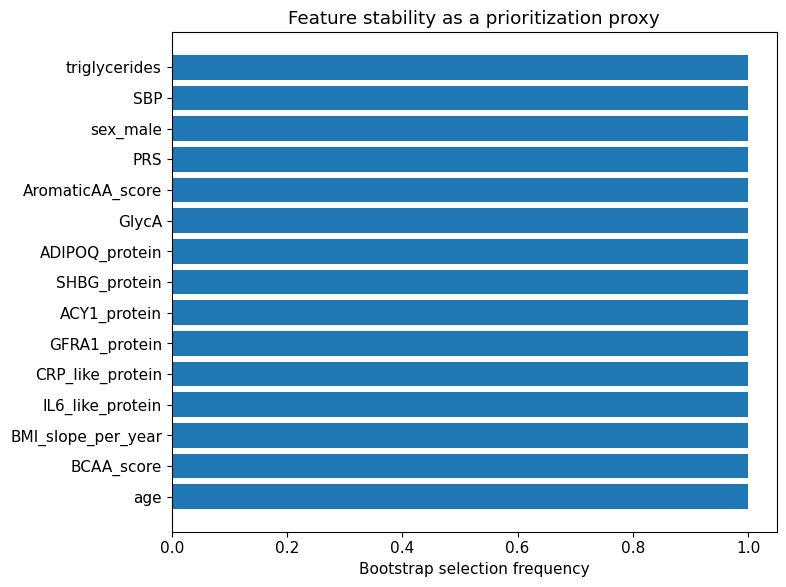

In [36]:

# 13. Feature-stability analysis as a prioritization proxy

candidate_for_stability = clinical_features + ["PRS"] + [
    "BCAA_score", "AromaticAA_score", "GlycA",
    "ADIPOQ_protein", "SHBG_protein", "ACY1_protein", "GFRA1_protein",
    "CRP_like_protein", "IL6_like_protein",
    "BMI_slope_per_year", "HbA1c_slope_per_year"
]
candidate_for_stability = [c for c in candidate_for_stability if c in df_model.columns]

X_stab = df_model[candidate_for_stability].copy()
y_stab = df_model[target].values

select_counts = pd.Series(0, index=candidate_for_stability, dtype=float)
rng = np.random.default_rng(42)

for b in range(100):
    idx = rng.choice(np.arange(len(X_stab)), size=len(X_stab), replace=True)
    Xb = X_stab.iloc[idx]
    yb = y_stab[idx]

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1", solver="saga", C=0.2, max_iter=4000,
            class_weight="balanced", random_state=42+b
        ))
    ])
    pipe.fit(Xb, yb)
    coef = pipe.named_steps["model"].coef_[0]
    select_counts += (np.abs(coef) > 1e-6).astype(int)

stability_df = pd.DataFrame({
    "feature": candidate_for_stability,
    "selection_frequency": (select_counts / 100).values
}).sort_values("selection_frequency", ascending=False)

print(stability_df)

plt.figure(figsize=(8, 6))
top_stable = stability_df.head(15).sort_values("selection_frequency")
plt.barh(top_stable["feature"], top_stable["selection_frequency"])
plt.xlabel("Bootstrap selection frequency")
plt.title("Feature stability as a prioritization proxy")
plt.tight_layout()
plt.show()



### Interpretation

This is a simple *stability selection* style analysis.

Instead of asking only whether a feature is important once, it asks whether the feature is selected **repeatedly across bootstrap resamples**.

Features that appear again and again are often better prioritisation candidates than features that appear only intermittently.

This is still not causal inference, but it is a useful bridge between:
- pure prediction,
- feature ranking,
- and biomarker prioritisation.


In [40]:

# 14. Final summary and export

print("\nFINAL SUMMARY \n")
print("Best feature set:", best_name)
print("\nPerformance table:")
print(perf_table.round(3))

print("\nTop stable features:")
print(stability_df.head(10).to_string(index=False))

print("\nTop permutation importance features:")
print(perm_df.head(10).to_string(index=False))

print("\nRisk decile event rates:")
print(risk_decile_event.to_string(index=False))

perf_table.round(4).to_csv("simulated_t2d_model_performance.csv")
uni_df.to_csv("simulated_t2d_univariate_associations.csv", index=False)
stability_df.to_csv("simulated_t2d_stability_selection.csv", index=False)
perm_df.to_csv("simulated_t2d_permutation_importance.csv", index=False)
subgroup_df.to_csv("simulated_t2d_subgroup_performance.csv", index=False)
risk_decile_event.to_csv("simulated_t2d_risk_deciles.csv", index=False)

print("\nSaved CSV files to ")



FINAL SUMMARY 

Best feature set: Clinical

Performance table:
                                AUROC  AUPRC  Brier  Accuracy     F1    ECE  \
Clinical                        0.793  0.070  0.256     0.714  0.077  0.289   
Clinical+PRS                    0.759  0.093  0.224     0.752  0.075  0.247   
Clinical+MultiOmics             0.743  0.065  0.157     0.831  0.092  0.168   
Clinical+MultiOmics+Trajectory  0.740  0.063  0.146     0.841  0.083  0.157   
Clinical+Proteins               0.719  0.085  0.231     0.746  0.075  0.257   
Clinical+Metabolites            0.614  0.058  0.145     0.830  0.066  0.170   

                                AUROC_95CI_low  AUROC_95CI_high  
Clinical                                 0.738            0.846  
Clinical+PRS                             0.689            0.832  
Clinical+MultiOmics                      0.663            0.817  
Clinical+MultiOmics+Trajectory           0.664            0.812  
Clinical+Proteins                        0.641      


### Interpretation

This final block consolidates the key outputs and exports the most useful summary tables.

In a real project, these tables would be the starting point for:
- a Results section,
- figure legends,
- a model card,
- or a translational prioritisation report.

The overall message of the notebook is simple:

**Longitudinal multi-omics can improve disease prediction, but the gain should be examined alongside calibration, subgroup robustness, and feature stability, not only headline AUROC.**
